# Baseline model (v0)

**CST4275 Master's Individual Thesis — Swetank Mohanty (M01087647)**
Supervisor: Dr Siddhaling Urolagin, Middlesex University Dubai

Four recommendation modules over the master dataset, each evaluated under three relevance
protocols with seven metrics.

| # | Module | Input | Proposal |
|---|---|---|---|
| 1 | Demographic chart | vote counts and means, no content | §2 |
| 2 | Combined CB | genres + keywords + cast + director + overview + genome tags | §1 |
| 3 | Plot-description | overview only | §3 |
| 4 | Metadata | cast + director + genres + keywords, no overview | §4 |

Modules 2-4 are each built twice, once with SBERT (`all-MiniLM-L6-v2`) and once with TF-IDF, on
identical film sets and identical splits, so the deep-versus-classical comparison in Objective 5
is controlled rather than anecdotal.

**Structure note.** Everything below is written to be lifted into a class with no redesign:
`Representation` holds data, `ContentRecommender` holds behaviour, the metric functions are pure,
and the protocols take a recommender and return a row of results. Section 11 lists the mapping.

## 0. Configuration

In [ ]:
from pydantic import Settings
from pydantic_settings import BaseSettings

class ModelConfig(BaseSettings):
    pass

baseline_config = new ModelConfig()

In [1]:
# Every knob in one place. Raise MAX_ITEMS and N_USERS for the final thesis numbers;
# the defaults are sized so a first run finishes in a few minutes.
MAX_ITEMS = 25_000       # None = whole catalogue. Applied to EVERY representation.
N_USERS = 2_000          # sampled test users for the profile protocol
N_SEED_ITEMS = 1_000     # seed films for the item-to-item protocol
K_VALUES = (5, 10, 20)
K_PRIMARY = 10

LIKE_THRESHOLD = 4.0     # a rating at or above this counts as a positive
MIN_TRAIN_LIKES = 5      # a test user needs this many liked films before the cut-off
MIN_TEST_LIKES = 1
TEMPORAL_SPLIT_Q = 0.80  # global timestamp quantile separating train from test

GENOME_TAGS_PER_FILM = 15
COLD_VOTE_THRESHOLD = 10  # "cold" = fewer than this many MovieLens ratings

SBERT_MODEL = "all-MiniLM-L6-v2"
SBERT_BATCH = 128
RANDOM_STATE = 42

print(f"MAX_ITEMS={MAX_ITEMS}  N_USERS={N_USERS}  K={K_VALUES}")
print("Absolute metric values depend on MAX_ITEMS (a smaller catalogue inflates recall).")
print("Comparisons between modules are valid at any setting; absolute values are not")
print("comparable across different MAX_ITEMS.")

MAX_ITEMS=25000  N_USERS=2000  K=(5, 10, 20)
Absolute metric values depend on MAX_ITEMS (a smaller catalogue inflates recall).
Comparisons between modules are valid at any setting; absolute values are not
comparable across different MAX_ITEMS.


In [2]:
from __future__ import annotations

import hashlib
import json
import sys
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import scipy.sparse as sp
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.utils.extmath import safe_sparse_dot

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.autolayout": True,
    "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.labelsize": 10, "axes.edgecolor": "#666666", "font.size": 10,
})
INK, ACCENT, MUTED = "#1F3864", "#4472C4", "#A6A6A6"
POS, NEG = "#2E7D5B", "#B4462F"

rng = np.random.default_rng(RANDOM_STATE)
print(f"python {sys.version.split()[0]} | polars {pl.__version__} | numpy {np.__version__}")

python 3.12.13 | polars 1.43.0 | numpy 2.3.5


In [3]:
def find_project_root(marker: str = "datasets") -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"no ancestor of {here} contains a {marker!r} directory")


ROOT = find_project_root()
PROC = ROOT / "datasets" / "processed"
RAW = ROOT / "datasets" / "raw"
FIGS = ROOT / "outputs" / "figures"
ARTIFACTS = ROOT / "models" /"baseline_v0"
for d in (FIGS, ARTIFACTS):
    d.mkdir(parents=True, exist_ok=True)

LIST_COLUMNS = ("genres", "keywords", "cast_top", "directors",
                "production_companies", "production_countries", "spoken_languages", "ml_tags")


def load_table(stem: str, *, base: Path = None, separator: str = "|", lazy: bool = False):
    """Load a build artefact, preferring Parquet and falling back to CSV.

    The build pipeline defaults to CSV, which cannot store nested columns, so the
    list columns arrive as `separator`-delimited strings and are re-split here.
    """
    base = base or PROC
    parquet, csv = base / f"{stem}.parquet", base / f"{stem}.csv"
    if parquet.exists():
        frame = pl.scan_parquet(parquet) if lazy else pl.read_parquet(parquet)
    elif csv.exists():
        frame = pl.scan_csv(csv, infer_schema_length=10_000) if lazy \
            else pl.read_csv(csv, infer_schema_length=10_000)
        present = [c for c in LIST_COLUMNS if c in frame.collect_schema().names()]
        if present:
            frame = frame.with_columns([
                pl.when(pl.col(c).is_null() | (pl.col(c) == ""))
                  .then(pl.lit([], dtype=pl.List(pl.String)))
                  .otherwise(pl.col(c).str.split(separator)).alias(c)
                for c in present])
    else:
        raise FileNotFoundError(f"neither {parquet.name} nor {csv.name} in {base}")
    return frame


def save_fig(fig, name: str) -> None:
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight", facecolor="white")


print(f"root {ROOT}")

root D:\Middlesex University Dubai\CST4275\cb-movies-recommender


## 1. Master dataset and genome enrichment

In [4]:
master = load_table("movies_merged")
print(f"master dataset: {master.height:,} films x {master.width} columns")

genome_path = PROC / "genome_top_tags.parquet"
if genome_path.exists():
    genome = pl.read_parquet(genome_path)
else:
    # Built once from the 415 MB genome-scores file, then cached. Streaming scan:
    # the raw file is never held in memory.
    src = next((RAW / f / "genome-scores.csv" for f in ("movielens-full", "movielens-latest")
                if (RAW / f / "genome-scores.csv").exists()), None)
    if src is None:
        raise FileNotFoundError("genome-scores.csv not found under datasets/raw")
    tags = pl.scan_csv(src.parent / "genome-tags.csv",
                       schema_overrides={"tagId": pl.Int16, "tag": pl.String})
    genome = (pl.scan_csv(src, schema_overrides={"movieId": pl.Int32, "tagId": pl.Int16,
                                                 "relevance": pl.Float32})
              .join(tags, on="tagId")
              .sort(["relevance", "tag"], descending=[True, False])
              .group_by("movieId", maintain_order=True)
              .agg(pl.col("tag").head(GENOME_TAGS_PER_FILM).alias("genome_tags"))
              .rename({"movieId": "movie_id"}).sort("movie_id")
              .collect(engine="streaming"))
    genome.write_parquet(genome_path)

master = (master.join(genome, on="movie_id", how="left")
                .with_columns(pl.col("genome_tags").fill_null(pl.lit([], dtype=pl.List(pl.String)))))
master = master.with_columns((pl.col("genome_tags").list.len() > 0).alias("has_genome"))

n_genome = int(master["has_genome"].sum())
print(f"genome coverage: {n_genome:,} films ({n_genome / master.height:.1%})")
print("Only a seventh of the catalogue carries genome tags, so every result for the combined")
print("module is reported split by has_genome rather than averaged over the difference.")

master dataset: 89,178 films x 52 columns
genome coverage: 13,176 films (14.8%)
Only a seventh of the catalogue carries genome tags, so every result for the combined
module is reported split by has_genome rather than averaged over the difference.


## 2. The evaluation catalogue

One subset, shared by every representation. Comparing SBERT against TF-IDF only means something
if both see the same films, and `MAX_ITEMS` is the single knob that decides how many. The sample
is random rather than popularity-ranked so the vote-count distribution — and therefore the
cold-start population — survives intact.

In [5]:
eligible = master.filter(
    pl.col("has_overview") & (pl.col("metadata_soup").fill_null("").str.strip_chars() != "")
)
if MAX_ITEMS is not None and eligible.height > MAX_ITEMS:
    idx = rng.choice(eligible.height, size=MAX_ITEMS, replace=False)
    catalogue = eligible[np.sort(idx)]
else:
    catalogue = eligible

catalogue = catalogue.with_row_index("row")
MOVIE_IDS = catalogue["movie_id"].to_numpy()
ROW_OF = {int(m): i for i, m in enumerate(MOVIE_IDS)}
N_ITEMS = catalogue.height

print(f"eligible films (overview + soup): {eligible.height:,}")
print(f"evaluation catalogue           : {N_ITEMS:,}")
print(f"  with genome tags             : {int(catalogue['has_genome'].sum()):,}")
print(f"  with zero MovieLens ratings  : "
      f"{int((catalogue['ml_rating_count'].fill_null(0) == 0).sum()):,}")

GENRE_SETS = [set(g) for g in catalogue["genres"].to_list()]
ALL_GENRES = sorted({g for s in GENRE_SETS for g in s})
print(f"  distinct genres              : {len(ALL_GENRES)}")

eligible films (overview + soup): 86,825
evaluation catalogue           : 25,000
  with genome tags             : 3,738
  with zero MovieLens ratings  : 1,658
  distinct genres              : 22


## 3. Corpora

In [6]:
def join_tokens(col: str) -> pl.Expr:
    """Lowercase a list column and strip internal whitespace, then join with spaces.

    "Tom Hanks" becomes "tomhanks" so a vectoriser treats the actor as one term
    rather than crediting two films for sharing a first name.
    """
    return (pl.col(col).list.eval(
        pl.element().str.to_lowercase().str.replace_all(r"\s+", "")).list.join(" "))


corpora_exprs = {
    # Module 2: everything the build pipeline knows about a film.
    "combined": pl.concat_str([
        join_tokens("genres"), join_tokens("keywords"), join_tokens("cast_top"),
        join_tokens("directors"), join_tokens("genome_tags"),
        pl.col("overview_text").fill_null("").str.to_lowercase(),
    ], separator=" ", ignore_nulls=True),
    # Module 3: narrative only.
    "plot": pl.col("overview_text").fill_null("").str.to_lowercase(),
    # Module 4: structured attributes only, deliberately excluding the overview.
    "metadata": pl.concat_str([
        join_tokens("cast_top"), join_tokens("directors"),
        join_tokens("genres"), join_tokens("keywords"),
    ], separator=" ", ignore_nulls=True),
}

CORPORA = {name: catalogue.select(expr.alias("doc"))["doc"].to_list()
           for name, expr in corpora_exprs.items()}

summary = pd.DataFrame([
    {"corpus": name,
     "mean tokens": np.mean([len(d.split()) for d in docs]),
     "empty docs": sum(1 for d in docs if not d.strip())}
    for name, docs in CORPORA.items()
])
display(summary.round(1))
print("\nexample (combined):", CORPORA["combined"][0][:220], "...")

,corpus,mean tokens,empty docs
0,combined,61.6,0
1,plot,52.0,0
2,metadata,7.3,48



example (combined): animation comedy family jealousy toy boy friendship friends rivalry boynextdoor newtoy toycomestolife tomhanks timallen donrickles johnlasseter toys computeranimation pixaranimation animation kidsandfamily kids pixar car ...


## 4. Representations

`Representation` is a dumb container: a row-normalised matrix plus the `movie_id` for each row.
Keeping the id map alongside the matrix is what stops one representation being indexed with
another's row positions once populations differ.

In [7]:
@dataclass(frozen=True)
class Representation:
    """A row-normalised design matrix over the evaluation catalogue."""

    name: str
    corpus: str
    encoder: str          # "tfidf" or "sbert"
    matrix: Any           # csr_matrix or float32 ndarray, L2-normalised rows
    movie_ids: np.ndarray
    build_seconds: float = 0.0

    @property
    def n_features(self) -> int:
        return self.matrix.shape[1]

    def __repr__(self) -> str:
        return (f"<Representation {self.name}: {self.matrix.shape[0]:,} films "
                f"x {self.n_features:,} dims>")


TFIDF_PARAMS = dict(stop_words="english", min_df=3, max_df=0.5, ngram_range=(1, 2),
                    sublinear_tf=True, max_features=120_000, dtype=np.float32)

representations: dict[str, Representation] = {}
vectorizers: dict[str, TfidfVectorizer] = {}

for corpus, docs in CORPORA.items():
    t = time.time()
    vec = TfidfVectorizer(**TFIDF_PARAMS)
    matrix = normalize(vec.fit_transform(docs).astype(np.float32))
    name = f"{corpus}_tfidf"
    representations[name] = Representation(name, corpus, "tfidf", matrix,
                                           MOVIE_IDS, time.time() - t)
    vectorizers[name] = vec
    print(f"{name:20} {matrix.shape[0]:,} x {matrix.shape[1]:,}  "
          f"nnz/row {matrix.nnz / matrix.shape[0]:.0f}  ({time.time() - t:.0f}s)")

combined_tfidf       25,000 x 54,135  nnz/row 39  (14s)
plot_tfidf           25,000 x 38,811  nnz/row 28  (10s)
metadata_tfidf       25,000 x 13,805  nnz/row 8  (2s)


In [8]:
def load_encoder(model_name: str):
    """Return a sentence-transformer, or None when the model cannot be obtained.

    Missing weights should downgrade the notebook to a TF-IDF-only comparison
    rather than aborting a run that is otherwise complete.
    """
    try:
        from sentence_transformers import SentenceTransformer
    except ImportError:
        print("sentence-transformers not installed:  uv add sentence-transformers")
        return None
    try:
        return SentenceTransformer(model_name)
    except Exception as exc:                                   # offline, proxy, no cache
        print(f"could not load {model_name!r}: {type(exc).__name__}")
        print("SBERT modules will be skipped; TF-IDF results below are unaffected.")
        return None


def corpus_fingerprint(docs: list[str], model_name: str) -> str:
    """Identity of an encoding job: the exact documents and the exact model."""
    digest = hashlib.sha256(model_name.encode())
    digest.update(str(len(docs)).encode())
    for doc in docs:
        digest.update(doc.encode("utf-8", "ignore"))
        digest.update(b"\x1f")
    return digest.hexdigest()[:16]


def encode_corpus(encoder, docs: list[str], cache: Path, *,
                  model_name: str = SBERT_MODEL, batch: int = SBERT_BATCH):
    """Encode `docs` to L2-normalised float32, caching to `cache`.

    Encoding is the slowest step in the notebook, so the cache is what makes a
    second run cheap. The key is a fingerprint of the documents and the model
    name, not the row count: MAX_ITEMS, the random sample or the model can all
    change while the count stays identical, and reusing a stale cache would
    silently evaluate the wrong embeddings.
    """
    want = corpus_fingerprint(docs, model_name)
    if cache.exists():
        stored = np.load(cache, allow_pickle=False)
        if str(stored.get("fingerprint", np.array("")).item()) == want:
            print(f"  reused {cache.name}")
            return stored["embeddings"]
        print(f"  {cache.name} is stale (different docs or model) — re-encoding")
    t = time.time()
    emb = encoder.encode(docs, batch_size=batch, normalize_embeddings=True,
                         convert_to_numpy=True, show_progress_bar=True).astype(np.float32)
    np.savez_compressed(cache, embeddings=emb, fingerprint=np.array(want),
                        model=np.array(model_name))
    print(f"  encoded {len(docs):,} docs in {time.time() - t:.0f}s -> {emb.shape}")
    return emb


ENCODER = load_encoder(SBERT_MODEL)
SBERT_AVAILABLE = ENCODER is not None

if SBERT_AVAILABLE:
    for corpus, docs in CORPORA.items():
        t = time.time()
        emb = encode_corpus(ENCODER, docs, ARTIFACTS / f"sbert_{corpus}.npz")
        name = f"{corpus}_sbert"
        representations[name] = Representation(name, corpus, "sbert", emb,
                                               MOVIE_IDS, time.time() - t)

print(f"\n{len(representations)} representations: {list(representations)}")


  reused sbert_combined.npz
  reused sbert_plot.npz
  reused sbert_metadata.npz

6 representations: ['combined_tfidf', 'plot_tfidf', 'metadata_tfidf', 'combined_sbert', 'plot_sbert', 'metadata_sbert']


## 5. Module 1 — demographic chart

The IMDb weighted rating, `WR = v/(v+m)·R + m/(v+m)·C`.

One correction is applied here. TMDB `vote_average` is a 0-10 scale and MovieLens
`ml_rating_mean` is 0.5-5, so the `weighted_rating` column in the master dataset blends
incompatible ranges and systematically depresses any film with MovieLens ratings. Both sources
are mapped to 0-10 before blending.

In [9]:
ML_TO_TMDB_SCALE = 2.0        # MovieLens 0.5-5 -> 0-10


def weighted_rating(mean: np.ndarray, votes: np.ndarray, quantile: float = 0.90):
    """IMDb weighted rating plus the (m, C) constants it was computed with."""
    votes = np.nan_to_num(votes, nan=0.0)
    qualifying = votes > 0
    m = float(np.quantile(votes[qualifying], quantile)) if qualifying.any() else 0.0
    c = float(np.nanmean(mean[qualifying])) if qualifying.any() else 0.0
    r = np.where(np.isnan(mean), c, mean)
    return (votes / (votes + m)) * r + (m / (votes + m)) * c, m, c


chart = catalogue.select("movie_id", "title_clean", "release_year", "genres",
                         "tmdb_vote_average", "tmdb_vote_count",
                         "ml_rating_mean", "ml_rating_count").to_pandas()

wr_tmdb, m_t, c_t = weighted_rating(chart["tmdb_vote_average"].to_numpy(float),
                                    chart["tmdb_vote_count"].to_numpy(float))
wr_ml, m_m, c_m = weighted_rating(chart["ml_rating_mean"].to_numpy(float) * ML_TO_TMDB_SCALE,
                                  chart["ml_rating_count"].to_numpy(float))

has_t = np.nan_to_num(chart["tmdb_vote_count"].to_numpy(float)) > 0
has_m = np.nan_to_num(chart["ml_rating_count"].to_numpy(float)) > 0
chart["wr_tmdb"], chart["wr_ml"] = wr_tmdb, wr_ml
chart["weighted_rating"] = np.select(
    [has_t & has_m, has_m, has_t],
    [(wr_tmdb + wr_ml) / 2, wr_ml, wr_tmdb],
    default=np.nan)

print(f"constants: m_tmdb={m_t:,.0f} C_tmdb={c_t:.3f} | m_ml={m_m:,.0f} C_ml={c_m:.3f}")
print("\nTop 15 — demographic chart (cold-start / anonymous users):")
display(chart.nlargest(15, "weighted_rating")[
    ["title_clean", "release_year", "tmdb_vote_average", "ml_rating_mean",
     "ml_rating_count", "weighted_rating"]].round(3).reset_index(drop=True))


def demographic_topk(k: int = K_PRIMARY, genre: str | None = None) -> np.ndarray:
    """Popularity ranking, optionally within a genre. Returns movie_ids."""
    frame = chart
    if genre is not None:
        mask = [genre in s for s in GENRE_SETS]
        frame = chart[np.asarray(mask)]
    return frame.nlargest(k, "weighted_rating")["movie_id"].to_numpy()

constants: m_tmdb=145 C_tmdb=5.962 | m_ml=279 C_ml=6.019

Top 15 — demographic chart (cold-start / anonymous users):


,title_clean,release_year,tmdb_vote_average,ml_rating_mean,ml_rating_count,weighted_rating
0,Parasite,2019.0,8.515,4.330,12399.0,8.547
1,Schindler's List,1993.0,8.300,4.242,84232.0,8.351
2,Spirited Away (Sen to Chihiro no kamikakushi),2001.0,8.300,4.226,35375.0,8.325
3,12 Angry Men,1957.0,8.200,4.267,22730.0,8.281
4,The Usual Suspects,1995.0,8.100,4.268,72893.0,8.269
5,Your Name.,2016.0,8.500,4.168,3940.0,8.184
6,Seven Samurai (Shichinin no samurai),1954.0,8.200,4.251,17120.0,8.174
7,Léon: The Professional (a.k.a. The Professiona...,1994.0,8.200,4.098,43539.0,8.154
8,Star Wars: Episode IV - A New Hope,1977.0,8.100,4.092,97202.0,8.117
9,"Good, the Bad and the Ugly, The (Buono, il bru...",1966.0,8.100,4.132,23823.0,8.107


## 6. Modules 2-4 — content recommenders

One class serves all three. The corpus decides which module it is; the encoder decides whether
it is the SBERT or the TF-IDF arm.

In [10]:
class ContentRecommender:
    """Cosine retrieval over a row-normalised representation.

    Works unchanged for sparse TF-IDF and dense SBERT matrices because both are
    L2-normalised, which makes cosine similarity a plain dot product.
    """

    def __init__(self, rep: Representation, catalogue: pl.DataFrame):
        self.rep = rep
        self.matrix = rep.matrix
        self.movie_ids = rep.movie_ids
        self.row_of = {int(m): i for i, m in enumerate(rep.movie_ids)}
        self.titles = catalogue["title_clean"].to_list()

    def __repr__(self) -> str:
        return f"<ContentRecommender {self.rep.name}>"

    @staticmethod
    def _dense(product) -> np.ndarray:
        """Densify a dot product.

        `np.asarray` on a sparse result returns a 0-d object array rather than
        a matrix, so sparse output has to be converted explicitly.
        """
        return product.toarray() if sp.issparse(product) else np.asarray(product)

    def _scores(self, query) -> np.ndarray:
        return self._dense(safe_sparse_dot(self.matrix, query.T)).ravel()

    def similar(self, movie_id: int, k: int = K_PRIMARY) -> np.ndarray:
        """Top-k most similar films to `movie_id`, excluding itself."""
        row = self.row_of[int(movie_id)]
        scores = self._scores(self.matrix[row])
        scores[row] = -np.inf
        return self.movie_ids[top_k_indices(scores, k)]

    def recommend_profiles(self, profiles, k: int, seen: list[set[int]] | None = None,
                           block: int = 256) -> np.ndarray:
        """Score a batch of user profiles and return their top-k movie_ids.

        Blocked so peak memory stays at block x n_items rather than
        n_users x n_items, which at full scale would not fit.
        """
        out = np.empty((profiles.shape[0], k), dtype=np.int32)
        for start in range(0, profiles.shape[0], block):
            chunk = profiles[start:start + block]
            scores = self._dense(safe_sparse_dot(chunk, self.matrix.T))
            if seen is not None:
                for i, already in enumerate(seen[start:start + block]):
                    rows = [self.row_of[m] for m in already if m in self.row_of]
                    if rows:
                        scores[i, rows] = -np.inf
            for i in range(scores.shape[0]):
                out[start + i] = self.movie_ids[top_k_indices(scores[i], k)]
        return out

    def build_profiles(self, liked: list[np.ndarray]):
        """Mean of each user's liked item vectors, re-normalised.

        Expressed as one sparse selector matmul rather than a per-user loop:
        `selector` holds 1/n at (user, item), so `selector @ matrix` is every
        profile at once and stays sparse when the representation is sparse.
        """
        rows, cols, vals = [], [], []
        for u, items in enumerate(liked):
            idx = [self.row_of[int(m)] for m in items if int(m) in self.row_of]
            if not idx:
                continue
            rows.extend([u] * len(idx))
            cols.extend(idx)
            vals.extend([1.0 / len(idx)] * len(idx))
        selector = sp.csr_matrix(
            (np.asarray(vals, dtype=np.float32), (rows, cols)),
            shape=(len(liked), self.matrix.shape[0]), dtype=np.float32)
        profiles = selector @ self.matrix
        if sp.issparse(profiles):
            return normalize(profiles.tocsr())
        return normalize(np.asarray(profiles, dtype=np.float32))


def top_k_indices(scores: np.ndarray, k: int) -> np.ndarray:
    """Indices of the k largest scores, in descending order."""
    k = min(k, scores.shape[0] - 1)
    part = np.argpartition(-scores, k)[:k]
    return part[np.argsort(-scores[part])]


RECOMMENDERS = {name: ContentRecommender(rep, catalogue)
                for name, rep in representations.items()}
print(list(RECOMMENDERS))

['combined_tfidf', 'plot_tfidf', 'metadata_tfidf', 'combined_sbert', 'plot_sbert', 'metadata_sbert']


In [11]:
# Qualitative check before any metric is computed. If these lists look wrong, the
# numbers later will be measuring the wrong thing.
def show_similar(title: str, k: int = 6) -> None:
    matches = [i for i, t in enumerate(catalogue["title_clean"].to_list())
               if t.strip().casefold() == title.strip().casefold()]
    if not matches:
        print(f"{title!r} is not in the sampled catalogue"); return
    mid = int(MOVIE_IDS[matches[0]])
    print(f"\n=== {title} (movie_id={mid}) ===")
    for name, rec in RECOMMENDERS.items():
        names = [catalogue["title_clean"][rec.row_of[int(m)]] for m in rec.similar(mid, k)]
        print(f"  {name:18} {' | '.join(names)}")


for probe in ("Toy Story", "The Matrix", "Pulp Fiction"):
    show_similar(probe)


=== Toy Story (movie_id=1) ===
  combined_tfidf     Toy Story Toons: Hawaiian Vacation | Toy Story That Time Forgot | Hot Rod Huckster | Toy Story Toons: Partysaurus Rex | Lamp Life | Free Birds
  plot_tfidf         Hot Rod Huckster | The Dizzy Acrobat | Lost in London | The War Lover | Lazer Team 2 | Up On The Glass
  metadata_tfidf     Toy Story That Time Forgot | Scooby-Doo! The Sword and the Scoob | Ella Bella Bingo | Lamp Life | Toy Story Toons: Partysaurus Rex | The Hick Chick
  combined_sbert     A Pig's Tale | Dumb and Dumber To | Stuart Little | Fat Albert | Gnomeo & Juliet | Bebe's Kids
  plot_sbert         Hot Rod Huckster | Lazer Team 2 | Jill, Joy and the Sleeping Clock | Burt's Buzz | Gremlins 2: The New Batch | The 41-Year-Old Virgin Who Knocked Up Sarah Marshall and Felt Superbad About It
  metadata_sbert     Bolt | Happiness Is a Warm Blanket, Charlie Brown | Toy Story Toons: Partysaurus Rex | Oliver & Company | Doug's 1st Movie | Piglet's Big Movie
'The Matrix' is no

## 7. Metrics

Seven measures. The first three are accuracy against a relevance set; the last four describe the
character of the list, which is where content-based systems usually fail quietly by recommending
the same popular, homogeneous films to everyone.

In [12]:
def precision_at_k(recommended: np.ndarray, relevant: set[int], k: int) -> float:
    top = recommended[:k]
    return sum(1 for m in top if m in relevant) / k


def recall_at_k(recommended: np.ndarray, relevant: set[int], k: int) -> float:
    if not relevant:
        return np.nan
    top = recommended[:k]
    return sum(1 for m in top if m in relevant) / len(relevant)


def ndcg_at_k(recommended: np.ndarray, relevant: set[int], k: int) -> float:
    """Binary-gain NDCG. IDCG uses min(|relevant|, k) so a user with fewer
    relevant items than k can still reach 1.0."""
    if not relevant:
        return np.nan
    gains = np.array([1.0 if m in relevant else 0.0 for m in recommended[:k]])
    discounts = 1.0 / np.log2(np.arange(2, len(gains) + 2))
    dcg = float((gains * discounts).sum())
    ideal = float(discounts[:min(len(relevant), k)].sum())
    return dcg / ideal if ideal > 0 else np.nan


def intra_list_diversity(recommended: np.ndarray, k: int) -> float:
    """Mean pairwise genre dissimilarity (1 - Jaccard) within a list.

    Measured in genre space rather than the representation being evaluated:
    scoring a representation's diversity with its own similarity function is
    circular and always flatters whichever representation is sparser.
    """
    rows = [ROW_OF[int(m)] for m in recommended[:k] if int(m) in ROW_OF]
    if len(rows) < 2:
        return np.nan
    total, pairs = 0.0, 0
    for i in range(len(rows)):
        a = GENRE_SETS[rows[i]]
        for j in range(i + 1, len(rows)):
            b = GENRE_SETS[rows[j]]
            union = a | b
            total += 1.0 - (len(a & b) / len(union) if union else 0.0)
            pairs += 1
    return total / pairs if pairs else np.nan


def novelty(recommended: np.ndarray, popularity: dict[int, float], k: int) -> float:
    """Mean self-information, -log2(p(i)). Popular films score low."""
    vals = [-np.log2(max(popularity.get(int(m), 1e-9), 1e-9)) for m in recommended[:k]]
    return float(np.mean(vals)) if vals else np.nan


def genre_coverage(all_lists: np.ndarray, k: int) -> float:
    """Share of the catalogue's genres that appear anywhere in the recommendations."""
    seen = set()
    for row in all_lists:
        for m in row[:k]:
            idx = ROW_OF.get(int(m))
            if idx is not None:
                seen |= GENRE_SETS[idx]
    return len(seen) / len(ALL_GENRES) if ALL_GENRES else np.nan


def catalogue_coverage(all_lists: np.ndarray, k: int) -> float:
    """Share of the catalogue ever recommended to anyone."""
    seen = {int(m) for row in all_lists for m in row[:k]}
    return len(seen) / N_ITEMS

## 8. Interactions, popularity and the temporal split

In [13]:
inter = (load_table("interactions", lazy=True)
         .filter(pl.col("movie_id").is_in(MOVIE_IDS.tolist()))
         .collect(engine="streaming"))
print(f"interactions inside the evaluation catalogue: {inter.height:,}")

pop_counts = inter.group_by("movie_id").len()
n_users_total = inter["user_id"].n_unique()
POPULARITY = {int(m): c / n_users_total
              for m, c in zip(pop_counts["movie_id"], pop_counts["len"])}
print(f"users {n_users_total:,} | rated films {pop_counts.height:,}")

inter = inter.with_columns(
    pl.col("rated_at").str.to_datetime()  # Or .str.to_date() if it's just YYYY-MM-DD
)
cutoff = inter["rated_at"].quantile(TEMPORAL_SPLIT_Q)
print(f"temporal cut-off: {cutoff}  (train before, test after)")

likes = inter.filter(pl.col("rating") >= LIKE_THRESHOLD)
train = likes.filter(pl.col("rated_at") < cutoff)
test = likes.filter(pl.col("rated_at") >= cutoff)
print(f"positives: {likes.height:,}  train {train.height:,}  test {test.height:,}")

interactions inside the evaluation catalogue: 9,849,885
users 313,521 | rated films 23,342
temporal cut-off: 2018-03-19 18:36:50  (train before, test after)
positives: 4,842,546  train 3,879,887  test 962,659


## 9. Protocol A — user-profile leave-N-out

Each test user's profile is the mean of the representations of the films they liked before the
cut-off. Relevance is the set of films they liked after it. Films already seen in training are
masked out, so a module cannot score by recommending what the user has already watched.

In [14]:
train_by_user = train.group_by("user_id").agg(pl.col("movie_id").alias("train_items"))
test_by_user = test.group_by("user_id").agg(pl.col("movie_id").alias("test_items"))

users = (train_by_user.join(test_by_user, on="user_id", how="inner")
         .filter((pl.col("train_items").list.len() >= MIN_TRAIN_LIKES)
                 & (pl.col("test_items").list.len() >= MIN_TEST_LIKES)))
print(f"users with enough history on both sides: {users.height:,}")

if users.height > N_USERS:
    pick = rng.choice(users.height, size=N_USERS, replace=False)
    users = users[np.sort(pick)]

USER_TRAIN = [np.asarray(x) for x in users["train_items"].to_list()]
USER_TEST = [set(int(m) for m in x) for x in users["test_items"].to_list()]
print(f"evaluating {len(USER_TRAIN):,} users | "
      f"median train likes {np.median([len(x) for x in USER_TRAIN]):.0f}, "
      f"median test likes {np.median([len(x) for x in USER_TEST]):.0f}")

users with enough history on both sides: 6,985
evaluating 2,000 users | median train likes 42, median test likes 8


In [15]:
def evaluate_profiles(rec: ContentRecommender) -> dict:
    """Protocol A: score every sampled user's profile and average the metrics."""
    t = time.time()
    profiles = rec.build_profiles(USER_TRAIN)
    seen = [set(int(m) for m in items) for items in USER_TRAIN]
    lists = rec.recommend_profiles(profiles, max(K_VALUES), seen=seen)

    out = {"module": rec.rep.corpus, "encoder": rec.rep.encoder}
    for k in K_VALUES:
        out[f"P@{k}"] = float(np.mean([precision_at_k(r, rel, k)
                                       for r, rel in zip(lists, USER_TEST)]))
        out[f"R@{k}"] = float(np.nanmean([recall_at_k(r, rel, k)
                                          for r, rel in zip(lists, USER_TEST)]))
        out[f"NDCG@{k}"] = float(np.nanmean([ndcg_at_k(r, rel, k)
                                             for r, rel in zip(lists, USER_TEST)]))
    out["ILD"] = float(np.nanmean([intra_list_diversity(r, K_PRIMARY) for r in lists]))
    out["Novelty"] = float(np.nanmean([novelty(r, POPULARITY, K_PRIMARY) for r in lists]))
    out["GenreCov"] = genre_coverage(lists, K_PRIMARY)
    out["CatCov"] = catalogue_coverage(lists, K_PRIMARY)
    out["seconds"] = round(time.time() - t, 1)
    return out


# The demographic chart is not personalised: every user receives the same list.
def evaluate_demographic() -> dict:
    top = demographic_topk(max(K_VALUES))
    lists = np.tile(top, (len(USER_TEST), 1))
    out = {"module": "demographic", "encoder": "popularity"}
    for k in K_VALUES:
        out[f"P@{k}"] = float(np.mean([precision_at_k(top, rel, k) for rel in USER_TEST]))
        out[f"R@{k}"] = float(np.nanmean([recall_at_k(top, rel, k) for rel in USER_TEST]))
        out[f"NDCG@{k}"] = float(np.nanmean([ndcg_at_k(top, rel, k) for rel in USER_TEST]))
    out["ILD"] = intra_list_diversity(top, K_PRIMARY)
    out["Novelty"] = novelty(top, POPULARITY, K_PRIMARY)
    out["GenreCov"] = genre_coverage(lists, K_PRIMARY)
    out["CatCov"] = catalogue_coverage(lists, K_PRIMARY)
    out["seconds"] = 0.0
    return out


rows_a = [evaluate_demographic()]
for name, rec in RECOMMENDERS.items():
    rows_a.append(evaluate_profiles(rec))
    print(f"  {name} done ({rows_a[-1]['seconds']}s)")

protocol_a = pd.DataFrame(rows_a)
display(protocol_a.round(4))

  combined_tfidf done (10.8s)
  plot_tfidf done (8.5s)
  metadata_tfidf done (5.9s)
  combined_sbert done (2.4s)
  plot_sbert done (2.4s)
  metadata_sbert done (2.4s)


,module,encoder,P@5,R@5,NDCG@5,P@10,R@10,NDCG@10,P@20,R@20,NDCG@20,ILD,Novelty,GenreCov,CatCov,seconds
0,demographic,popularity,0.0928,0.0580,0.1355,0.0652,0.0762,0.1173,0.0590,0.1232,0.1240,0.8356,3.4360,0.6364,0.0004,0.0
1,combined,tfidf,0.0358,0.0174,0.0398,0.0316,0.0307,0.0403,0.0265,0.0522,0.0441,0.6312,8.9643,0.9091,0.0507,10.8
2,plot,tfidf,0.0086,0.0046,0.0112,0.0059,0.0054,0.0095,0.0044,0.0071,0.0091,0.7875,15.7662,0.9091,0.1097,8.5
3,metadata,tfidf,0.0048,0.0024,0.0063,0.0032,0.0028,0.0053,0.0020,0.0036,0.0048,0.2791,16.6258,0.9091,0.1135,5.9
4,combined,sbert,0.0108,0.0057,0.0121,0.0100,0.0101,0.0128,0.0097,0.0189,0.0150,0.6389,9.8662,0.9091,0.0339,2.4
5,plot,sbert,0.0007,0.0003,0.0008,0.0006,0.0004,0.0008,0.0005,0.0007,0.0008,0.8181,16.2308,0.9091,0.0457,2.4
6,metadata,sbert,0.0069,0.0019,0.0068,0.0077,0.0059,0.0082,0.0069,0.0118,0.0096,0.7057,10.1869,0.9091,0.0252,2.4


## 10. Protocol B — item-to-item co-occurrence

A different question: given a seed film, are the recommended films the ones users who liked the
seed also liked? Ground truth comes from co-liking counts, which is a collaborative signal, so
this protocol rewards popularity in a way protocol A does not. Reported alongside rather than
instead.

In [16]:
# Sparse user x item matrix over positives, then co-occurrence for the seed columns only.
u_codes, u_uniques = pd.factorize(likes["user_id"].to_numpy())
i_rows = np.array([ROW_OF[int(m)] for m in likes["movie_id"].to_numpy()])
UI = sp.csr_matrix((np.ones(len(u_codes), dtype=np.float32), (u_codes, i_rows)),
                   shape=(len(u_uniques), N_ITEMS))
print(f"user x item positives: {UI.shape[0]:,} x {UI.shape[1]:,}  nnz {UI.nnz:,}")

item_likes = np.asarray(UI.sum(axis=0)).ravel()
eligible_seeds = np.where(item_likes >= 20)[0]
seeds = rng.choice(eligible_seeds, size=min(N_SEED_ITEMS, len(eligible_seeds)), replace=False)
print(f"seed films (>=20 positives): {len(seeds):,}")

co = (UI[:, seeds].T @ UI).toarray()             # seeds x items
co[np.arange(len(seeds)), seeds] = 0             # a film never co-occurs with itself
GROUND_B = [set(MOVIE_IDS[top_k_indices(row, max(K_VALUES))].tolist()) for row in co]
SEED_IDS = MOVIE_IDS[seeds]
print(f"ground truth: top-{max(K_VALUES)} co-liked films per seed")

user x item positives: 292,314 x 25,000  nnz 4,842,546
seed films (>=20 positives): 1,000
ground truth: top-20 co-liked films per seed


In [17]:
def evaluate_item_to_item(rec: ContentRecommender) -> dict:
    t = time.time()
    lists = np.vstack([rec.similar(int(m), max(K_VALUES)) for m in SEED_IDS])
    out = {"module": rec.rep.corpus, "encoder": rec.rep.encoder}
    for k in K_VALUES:
        out[f"P@{k}"] = float(np.mean([precision_at_k(r, g, k)
                                       for r, g in zip(lists, GROUND_B)]))
        out[f"R@{k}"] = float(np.nanmean([recall_at_k(r, g, k)
                                          for r, g in zip(lists, GROUND_B)]))
        out[f"NDCG@{k}"] = float(np.nanmean([ndcg_at_k(r, g, k)
                                             for r, g in zip(lists, GROUND_B)]))
    out["ILD"] = float(np.nanmean([intra_list_diversity(r, K_PRIMARY) for r in lists]))
    out["Novelty"] = float(np.nanmean([novelty(r, POPULARITY, K_PRIMARY) for r in lists]))
    out["GenreCov"] = genre_coverage(lists, K_PRIMARY)
    out["CatCov"] = catalogue_coverage(lists, K_PRIMARY)
    out["seconds"] = round(time.time() - t, 1)
    return out


protocol_b = pd.DataFrame([evaluate_item_to_item(r) for r in RECOMMENDERS.values()])
display(protocol_b.round(4))

,module,encoder,P@5,R@5,NDCG@5,P@10,R@10,NDCG@10,P@20,R@20,NDCG@20,ILD,Novelty,GenreCov,CatCov,seconds
0,combined,tfidf,0.0406,0.0102,0.0461,0.0311,0.0156,0.0376,0.0245,0.0245,0.0306,0.6397,12.7633,1.0000,0.2381,12.1
1,plot,tfidf,0.0086,0.0022,0.0097,0.0056,0.0028,0.0072,0.0038,0.0038,0.0054,0.8034,16.0074,1.0000,0.2944,8.1
2,metadata,tfidf,0.0162,0.0040,0.0181,0.0102,0.0051,0.0133,0.0067,0.0067,0.0097,0.4699,16.2391,1.0000,0.2526,5.1
3,combined,sbert,0.0266,0.0066,0.0305,0.0214,0.0107,0.0256,0.0160,0.0160,0.0203,0.5757,12.9364,1.0000,0.2290,3.2
4,plot,sbert,0.0102,0.0026,0.0129,0.0070,0.0035,0.0097,0.0048,0.0048,0.0072,0.7437,15.7434,0.9091,0.2850,2.9
5,metadata,sbert,0.0194,0.0048,0.0219,0.0147,0.0074,0.0178,0.0112,0.0112,0.0143,0.5295,14.0807,1.0000,0.2479,3.0


## 11. Protocol C — genre-overlap proxy

Needs no interaction data, which is the point: it is the only protocol that can score films
nobody has rated, and it is what the cold-start section below uses. Relevance is sharing at least
two genres with the seed. It measures agreement with genre labels, not user satisfaction, so it
is a sanity check rather than evidence.

In [18]:
MIN_SHARED_GENRES = 2


def genre_relevant(row: int, limit: int = 400) -> set[int]:
    """Films sharing at least MIN_SHARED_GENRES genres with the film at `row`."""
    target = GENRE_SETS[row]
    if len(target) < MIN_SHARED_GENRES:
        return set()
    hits = [MOVIE_IDS[i] for i, s in enumerate(GENRE_SETS)
            if i != row and len(target & s) >= MIN_SHARED_GENRES]
    return set(int(m) for m in hits[:limit])


def evaluate_genre_overlap(rec: ContentRecommender, seed_rows: np.ndarray) -> dict:
    t = time.time()
    lists, truths = [], []
    for row in seed_rows:
        rel = genre_relevant(int(row))
        if not rel:
            continue
        lists.append(rec.similar(int(MOVIE_IDS[row]), max(K_VALUES)))
        truths.append(rel)
    lists = np.vstack(lists)
    out = {"module": rec.rep.corpus, "encoder": rec.rep.encoder, "seeds": len(truths)}
    for k in K_VALUES:
        out[f"P@{k}"] = float(np.mean([precision_at_k(r, g, k) for r, g in zip(lists, truths)]))
        out[f"NDCG@{k}"] = float(np.nanmean([ndcg_at_k(r, g, k)
                                             for r, g in zip(lists, truths)]))
    out["ILD"] = float(np.nanmean([intra_list_diversity(r, K_PRIMARY) for r in lists]))
    out["Novelty"] = float(np.nanmean([novelty(r, POPULARITY, K_PRIMARY) for r in lists]))
    out["CatCov"] = catalogue_coverage(lists, K_PRIMARY)
    out["seconds"] = round(time.time() - t, 1)
    return out


warm_seeds = rng.choice(N_ITEMS, size=min(300, N_ITEMS), replace=False)
protocol_c = pd.DataFrame([evaluate_genre_overlap(r, warm_seeds)
                           for r in RECOMMENDERS.values()])
display(protocol_c.round(4))

,module,encoder,seeds,P@5,NDCG@5,P@10,NDCG@10,P@20,NDCG@20,ILD,Novelty,CatCov,seconds
0,combined,tfidf,194,0.1392,0.1353,0.1345,0.1335,0.1330,0.1328,0.7199,15.7715,0.0718,5.1
1,plot,tfidf,194,0.0557,0.0558,0.0495,0.0514,0.0464,0.0486,0.8086,16.1525,0.0724,4.5
2,metadata,tfidf,194,0.2237,0.2170,0.2211,0.2175,0.2178,0.2165,0.3178,17.1390,0.0642,3.9
3,combined,sbert,194,0.2010,0.2084,0.1887,0.1977,0.1706,0.1818,0.6144,14.7185,0.0704,3.3
4,plot,sbert,194,0.0825,0.0873,0.0758,0.0809,0.0704,0.0753,0.7530,15.8794,0.0716,3.4
5,metadata,sbert,194,0.2320,0.2363,0.2196,0.2263,0.2072,0.2151,0.4259,15.5392,0.0704,3.6


## 12. Cold-start evaluation

The population that actually stresses a content-based system: films with almost no ratings. They
cannot appear in protocols A or B, because both derive relevance from ratings these films do not
have. Two questions are asked instead — can the modules produce sensible neighbours for a cold
film, and do cold films ever get recommended at all?

In [19]:
rating_counts = catalogue["ml_rating_count"].fill_null(0).to_numpy()
cold_rows = np.where(rating_counts < COLD_VOTE_THRESHOLD)[0]
warm_rows = np.where(rating_counts >= COLD_VOTE_THRESHOLD)[0]
print(f"cold films (<{COLD_VOTE_THRESHOLD} ratings): {len(cold_rows):,} "
      f"({len(cold_rows) / N_ITEMS:.1%})   warm: {len(warm_rows):,}")

cold_seeds = rng.choice(cold_rows, size=min(300, len(cold_rows)), replace=False)

rows_cold = []
for name, rec in RECOMMENDERS.items():
    res = evaluate_genre_overlap(rec, cold_seeds)
    res["population"] = "cold"
    # Exposure: what share of a module's recommendations to warm users are cold films?
    profiles = rec.build_profiles(USER_TRAIN[:500])
    lists = rec.recommend_profiles(profiles, K_PRIMARY)
    cold_ids = set(MOVIE_IDS[cold_rows].tolist())
    res["cold share of recs"] = float(np.mean([
        np.mean([int(m) in cold_ids for m in row]) for row in lists]))
    rows_cold.append(res)

cold_start = pd.DataFrame(rows_cold)
display(cold_start.round(4))
print("\n'cold share of recs' is the fraction of a personalised top-10 made up of films with")
print(f"fewer than {COLD_VOTE_THRESHOLD} ratings. A demographic chart scores 0 here by")
print("construction, which is the cold-start gap the content modules exist to close.")

cold films (<10 ratings): 15,840 (63.4%)   warm: 9,160


,module,encoder,seeds,P@5,NDCG@5,P@10,NDCG@10,P@20,NDCG@20,ILD,Novelty,CatCov,seconds,population,cold share of recs
0,combined,tfidf,180,0.0889,0.0889,0.0933,0.0922,0.0947,0.0934,0.7534,17.0389,0.0670,4.8,cold,0.0100
1,plot,tfidf,180,0.0378,0.0365,0.0356,0.0354,0.0375,0.0367,0.8026,16.2824,0.0675,4.2,cold,0.0358
2,metadata,tfidf,180,0.2400,0.2378,0.2239,0.2274,0.2250,0.2271,0.2669,17.4304,0.0585,3.6,cold,0.4958
3,combined,sbert,180,0.1767,0.1767,0.1639,0.1676,0.1631,0.1662,0.6009,15.5014,0.0657,3.3,cold,0.0606
4,plot,sbert,180,0.0711,0.0692,0.0644,0.0655,0.0597,0.0618,0.7517,16.2412,0.0671,3.1,cold,0.7254
5,metadata,sbert,180,0.2378,0.2343,0.2317,0.2311,0.2078,0.2154,0.3285,16.7489,0.0638,3.1,cold,0.1044



'cold share of recs' is the fraction of a personalised top-10 made up of films with
fewer than 10 ratings. A demographic chart scores 0 here by
construction, which is the cold-start gap the content modules exist to close.


## 13. Results

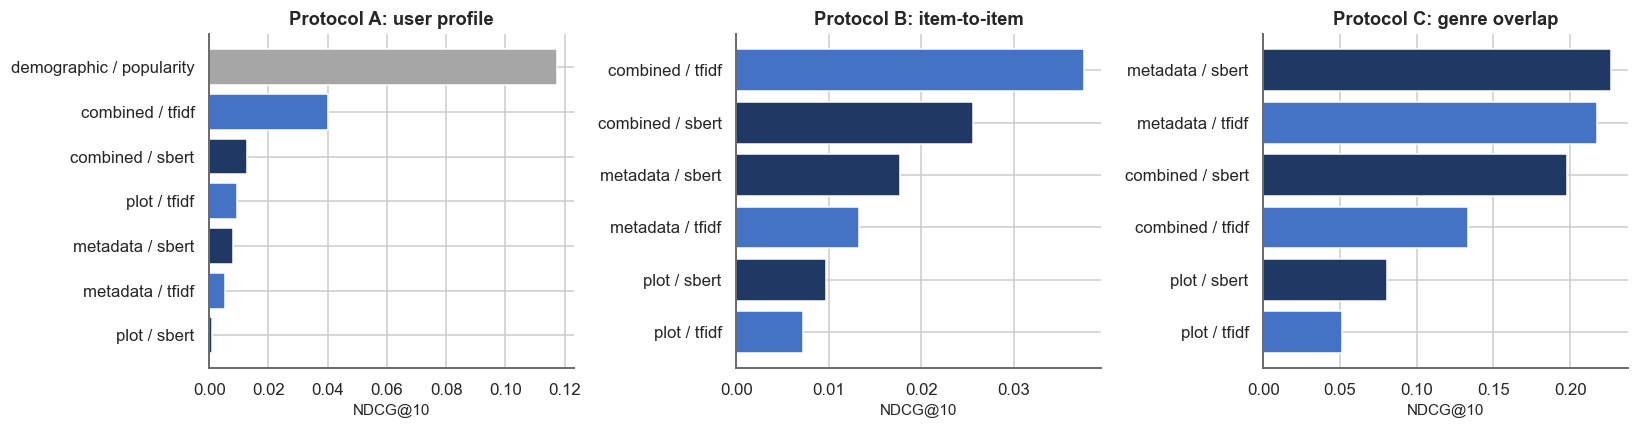

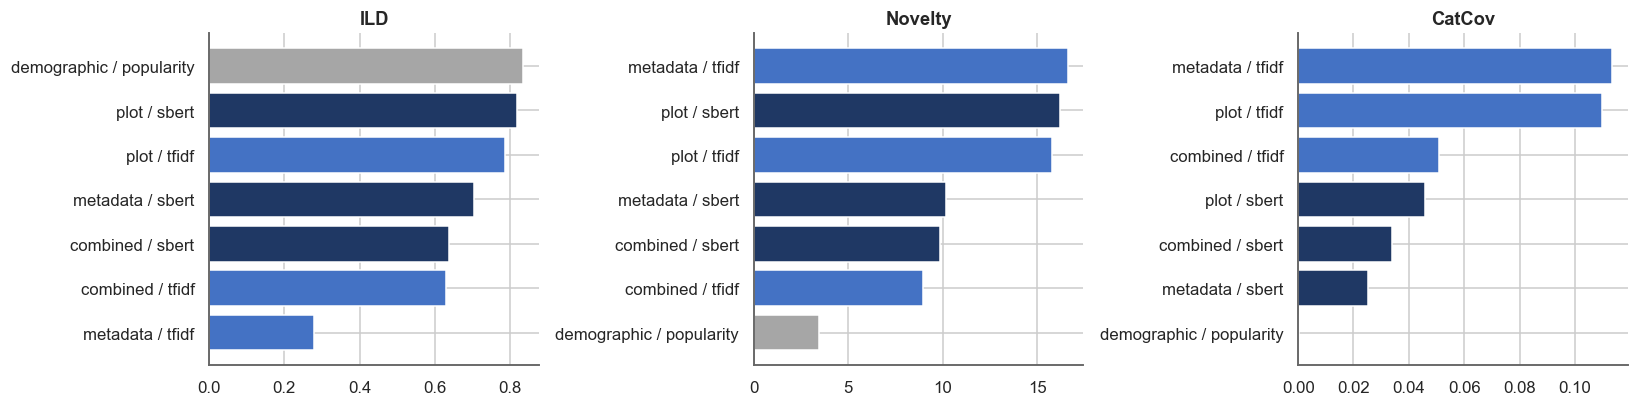

In [20]:
def label(frame: pd.DataFrame) -> pd.Series:
    return frame["module"] + " / " + frame["encoder"]


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, frame, title, metric in [
    (axes[0], protocol_a, "Protocol A: user profile", f"NDCG@{K_PRIMARY}"),
    (axes[1], protocol_b, "Protocol B: item-to-item", f"NDCG@{K_PRIMARY}"),
    (axes[2], protocol_c, "Protocol C: genre overlap", f"NDCG@{K_PRIMARY}"),
]:
    d = frame.copy()
    d["label"] = label(d)
    d = d.sort_values(metric, ascending=True)
    colours = [INK if e == "sbert" else ACCENT if e == "tfidf" else MUTED
               for e in d["encoder"]]
    ax.barh(d["label"], d[metric], color=colours)
    ax.set_title(title); ax.set_xlabel(metric)
sns.despine()
save_fig(fig, "baseline_ndcg_by_protocol")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, metric in zip(axes, ["ILD", "Novelty", "CatCov"]):
    d = protocol_a.copy(); d["label"] = label(d)
    d = d.sort_values(metric)
    ax.barh(d["label"], d[metric],
            color=[INK if e == "sbert" else ACCENT if e == "tfidf" else MUTED
                   for e in d["encoder"]])
    ax.set_title(metric)
sns.despine()
save_fig(fig, "baseline_beyond_accuracy")
plt.show()

In [21]:
if SBERT_AVAILABLE:
    merged = protocol_a.pivot(index="module", columns="encoder",
                              values=[f"NDCG@{K_PRIMARY}", "ILD", "Novelty"])
    display(merged.round(4))
    delta = (protocol_a[protocol_a.encoder == "sbert"]
             .set_index("module")[[f"NDCG@{K_PRIMARY}"]]
             - protocol_a[protocol_a.encoder == "tfidf"]
             .set_index("module")[[f"NDCG@{K_PRIMARY}"]])
    print("\nSBERT minus TF-IDF, NDCG@10 (positive favours SBERT):")
    display(delta.round(4))
else:
    print("SBERT unavailable in this environment — the head-to-head comparison in")
    print("Objective 5 needs a run with the model weights downloaded.")

NDCG@10                        ILD                    Novelty                  
encoder     popularity   sbert   tfidf popularity   sbert   tfidf popularity    sbert    tfidf
module                                                                                        
combined           NaN  0.0128  0.0403        NaN  0.6389  0.6312        NaN   9.8662   8.9643
demographic     0.1173     NaN     NaN     0.8356     NaN     NaN      3.436      NaN      NaN
metadata           NaN  0.0082  0.0053        NaN  0.7057  0.2791        NaN  10.1869  16.6258
plot               NaN  0.0008  0.0095        NaN  0.8181  0.7875        NaN  16.2308  15.7662


SBERT minus TF-IDF, NDCG@10 (positive favours SBERT):


,NDCG@10
module,
combined,-0.0275
plot,-0.0087
metadata,0.0029


In [22]:
# Combined module, split by genome coverage. Averaging across the two populations
# would hide whichever effect the genome tags actually have.
genome_ids = set(catalogue.filter(pl.col("has_genome"))["movie_id"].to_list())
rec = RECOMMENDERS["combined_tfidf"]
split_rows = []
for label_, rows in [("has genome", [r for r in warm_seeds
                                     if int(MOVIE_IDS[r]) in genome_ids]),
                     ("no genome", [r for r in warm_seeds
                                    if int(MOVIE_IDS[r]) not in genome_ids])]:
    if not rows:
        continue
    res = evaluate_genre_overlap(rec, np.asarray(rows))
    res["population"] = label_
    split_rows.append(res)
display(pd.DataFrame(split_rows).round(4))

,module,encoder,seeds,P@5,NDCG@5,P@10,NDCG@10,P@20,NDCG@20,ILD,Novelty,CatCov,seconds,population
0,combined,tfidf,38,0.3053,0.3044,0.2921,0.2968,0.2789,0.2858,0.6245,11.5065,0.0147,1.0,has genome
1,combined,tfidf,156,0.0987,0.0941,0.0962,0.0937,0.0974,0.0955,0.7431,16.8105,0.0580,3.5,no genome


## 14. Persist

In [23]:
protocol_a.to_csv(ARTIFACTS / "protocol_a_user_profile.csv", index=False)
protocol_b.to_csv(ARTIFACTS / "protocol_b_item_to_item.csv", index=False)
protocol_c.to_csv(ARTIFACTS / "protocol_c_genre_overlap.csv", index=False)
cold_start.to_csv(ARTIFACTS / "cold_start.csv", index=False)
chart.nlargest(500, "weighted_rating").to_csv(ARTIFACTS / "demographic_chart.csv", index=False)

manifest = {
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "config": {"MAX_ITEMS": MAX_ITEMS, "N_USERS": N_USERS, "N_SEED_ITEMS": N_SEED_ITEMS,
               "K_VALUES": list(K_VALUES), "LIKE_THRESHOLD": LIKE_THRESHOLD,
               "TEMPORAL_SPLIT_Q": TEMPORAL_SPLIT_Q, "RANDOM_STATE": RANDOM_STATE},
    "catalogue": {"films": N_ITEMS, "with_genome": int(catalogue["has_genome"].sum()),
                  "genres": len(ALL_GENRES)},
    "representations": {n: {"corpus": r.corpus, "encoder": r.encoder,
                            "dims": int(r.n_features), "build_seconds": round(r.build_seconds, 1)}
                        for n, r in representations.items()},
    "sbert_available": SBERT_AVAILABLE,
    "weighted_rating_constants": {"m_tmdb": m_t, "C_tmdb": c_t, "m_ml": m_m, "C_ml": c_m,
                                  "ml_to_tmdb_scale": ML_TO_TMDB_SCALE},
    "users_evaluated": len(USER_TRAIN),
}
(ARTIFACTS / "baseline_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
print(f"wrote artifacts to {ARTIFACTS.relative_to(ROOT)}")
display(pd.DataFrame([{"file": p.name, "KB": round(p.stat().st_size / 1024, 1)}
                      for p in sorted(ARTIFACTS.iterdir())]))

wrote artifacts to models\baseline_v0


,file,KB
0,baseline_manifest.json,1.4
1,cold_start.csv,1.3
2,demographic_chart.csv,69.0
3,protocol_a_user_profile.csv,1.8
4,protocol_b_item_to_item.csv,1.4
5,protocol_c_genre_overlap.csv,1.2
6,sbert_combined.npz,34764.5
7,sbert_metadata.npz,33134.5
8,sbert_plot.npz,34761.7


## 15. Dumping the model

One joblib file holding **plain data only** — numpy arrays, scipy sparse matrices, a pandas
frame, and the fitted scikit-learn vectorisers. No class defined in this notebook goes into it.

That restriction is the whole point. Pickling a `ContentRecommender` instance records it as
`__main__.ContentRecommender`, so `joblib.load` from a Streamlit app or any fresh process dies
with `AttributeError: Can't get attribute 'ContentRecommender' on <module '__main__'>`. Storing
data and rebuilding behaviour on load sidesteps that entirely, and survives the port to a class
without a re-dump.

On compression, measured on a bundle carrying SBERT embeddings: `compress=0` gives 136 MB,
dumps in 2.2s and loads in 0.9s; `compress=("zlib", 3)` gives 119 MB but takes 6.8s to dump.
A 12% saving for triple the dump time is a poor trade, because most of the bytes are dense
float32 embeddings and those are close to incompressible. Uncompressed is also the only setting
that supports `mmap_mode="r"`.

Whether to use `mmap` depends on how big the artefact actually is. With SBERT present it helps
(0.63s against 0.9s). On a TF-IDF-only bundle of about 21 MB it hurts (1.64s against 0.69s),
because setting up the mapping costs more than reading the file. The default is off.

A machine learning model for a recommender system is typically saved as a `.pkl` (Pickle) or `.joblib` file for `scikit-learn` models, or a `.h5` / `.keras` file if using deep learning frameworks like `TensorFlow`.

##### **Common File Extensions**

* `.pkl` / `.pickle`
    - Best for standard Python objects and smaller models.
    - Good for models built with scikit-learn or traditional matrix factorization algorithms.

* `.joblib`
    - Faster and more efficient for saving models with large NumPy arrays.
    - Highly recommended for scikit-learn models.

* `.h5` / `.keras`
    - Used for deep learning recommender models (like Neural Collaborative Filtering).
    - Standard format for `TensorFlow` / `Keras`.

* `.pt` / `.pth`
    - Used for deep learning models built with `PyTorch`.
 
#### **Best Practices**
* Match the extension to the library you use to train the model.
* Save the vectorizer or ID mappings (like user and item index encoders) together with the model file.

In [24]:
import joblib

MODEL_PATH = ARTIFACTS / "baseline_v0.joblib"

SERVE_COLUMNS = ["movie_id", "title_clean", "release_year", "genres",
                 "weighted_rating", "ml_rating_count", "has_genome"]


def dump_baseline(path: Path = MODEL_PATH, *, compress=0) -> Path:
    """Persist everything needed to serve recommendations, as plain data.

    `compress=0` is deliberate: it is both faster and the only setting that
    allows `mmap_mode="r"` on load. Pass compress=("zlib", 3) if the artefact
    has to travel over a slow link.
    """
    bundle = {
        "format_version": 1,
        "created_utc": pd.Timestamp.utcnow().isoformat(),
        "config": {"MAX_ITEMS": MAX_ITEMS, "K_VALUES": list(K_VALUES),
                   "LIKE_THRESHOLD": LIKE_THRESHOLD, "RANDOM_STATE": RANDOM_STATE,
                   "GENOME_TAGS_PER_FILM": GENOME_TAGS_PER_FILM},
        "movie_ids": MOVIE_IDS.astype(np.int32),
        # Only the columns needed at serve time. Carrying all 52 would triple the file.
        "catalogue": catalogue.select(SERVE_COLUMNS).to_pandas(),
        "representations": {
            name: {"corpus": r.corpus, "encoder": r.encoder, "matrix": r.matrix}
            for name, r in representations.items()
        },
        # Fitted vectorisers live in sklearn, not __main__, so they unpickle anywhere.
        # These are what encode an unseen film for the cold-start path.
        "vectorizers": vectorizers,
        "sbert_model_name": SBERT_MODEL if SBERT_AVAILABLE else None,
        "demographic": {
            "m_tmdb": m_t, "C_tmdb": c_t, "m_ml": m_m, "C_ml": c_m,
            "ml_to_tmdb_scale": ML_TO_TMDB_SCALE,
            "chart": chart.nlargest(1000, "weighted_rating")[
                ["movie_id", "title_clean", "release_year", "weighted_rating"]],
        },
        "popularity": POPULARITY,
    }
    path.parent.mkdir(parents=True, exist_ok=True)
    t = time.time()
    joblib.dump(bundle, path, compress=compress, protocol=5)
    size = path.stat().st_size / 1024**2
    print(f"wrote {path.name}: {size:,.1f} MB in {time.time() - t:.1f}s")
    return path


def load_baseline(path: Path = MODEL_PATH, *, mmap: bool = False) -> dict:
    """Load the bundle.

    `mmap=True` keeps large arrays on disk instead of copying them into memory,
    and only works on uncompressed dumps. It pays off once SBERT embeddings are
    present (~136 MB: 0.63s mmap against 0.9s full) and costs more than it saves
    on a TF-IDF-only bundle (~21 MB: 1.64s against 0.69s), where the mapping
    overhead dominates. Default off; turn it on for the large artefact.
    """
    try:
        return joblib.load(path, mmap_mode="r" if mmap else None)
    except ValueError:
        # joblib raises when mmap is requested on a compressed file.
        return joblib.load(path)


def rebuild_recommenders(bundle: dict) -> dict:
    """Reconstruct the recommenders from plain data.

    Needs `Representation` and `ContentRecommender` in scope. After the port they
    come from the package; in this notebook they are already defined above.
    """
    return {
        name: ContentRecommender(
            Representation(name, spec["corpus"], spec["encoder"],
                           spec["matrix"], bundle["movie_ids"]),
            bundle["catalogue"])
        for name, spec in bundle["representations"].items()
    }


dump_baseline()

wrote baseline_v0.joblib: 131.1 MB in 5.7s


WindowsPath('D:/Middlesex University Dubai/CST4275/cb-movies-recommender/models/baseline_v0/baseline_v0.joblib')

In [25]:
# Round trip. Reloading in this kernel proves little, because the classes are already
# defined here; the subprocess check below is the one that matters.
bundle = load_baseline()
restored = rebuild_recommenders(bundle)

probe = int(MOVIE_IDS[0])
for name, rec in restored.items():
    before = RECOMMENDERS[name].similar(probe, 5)
    after = rec.similar(probe, 5)
    assert np.array_equal(before, after), f"{name} changed across the round trip"
print(f"all {len(restored)} recommenders reproduce identical top-5 after reload")
print(f"vectorisers restored: {list(bundle['vectorizers'])}")
print(f"catalogue columns   : {list(bundle['catalogue'].columns)}")
print(f"file size           : {MODEL_PATH.stat().st_size / 1024**2:,.1f} MB")

all 6 recommenders reproduce identical top-5 after reload
vectorisers restored: ['combined_tfidf', 'plot_tfidf', 'metadata_tfidf']
catalogue columns   : ['movie_id', 'title_clean', 'release_year', 'genres', 'weighted_rating', 'ml_rating_count', 'has_genome']
file size           : 131.1 MB


---
## 16. Porting to a class

The notebook was written so this is a move, not a rewrite:

| Notebook object | Destination |
|---|---|
| Section 0 constants | `BaselineConfig` frozen dataclass |
| `Representation` | keep as-is |
| `ContentRecommender` | keep as-is |
| `weighted_rating`, `demographic_topk` | `DemographicRecommender` |
| `precision_at_k` … `catalogue_coverage` | `metrics.py`, pure functions, no globals |
| `evaluate_profiles`, `evaluate_item_to_item`, `evaluate_genre_overlap` | `Evaluator` |
| `load_table`, `encode_corpus` | `data.py` |

The one thing needing attention when porting: the metric functions currently close over the
module-level `ROW_OF`, `GENRE_SETS` and `MOVIE_IDS`. Pass those in explicitly rather than
importing them, otherwise the class carries hidden global state.

## Reading the numbers

Absolute values are tied to `MAX_ITEMS`. A 25,000-film catalogue makes recall look far better
than the full 89,178 would, because there are fewer wrong answers available. Comparisons between
modules at a fixed setting are sound; comparisons across settings are not.

Protocol B rewards popularity by construction, since its ground truth is built from co-ratings.
Expect the demographic chart and the metadata module to look stronger there than under protocol
A. That gap is a finding, not a defect.